# 1. 변수 전처리
: KFGI folder에서 Ridge, PCA, Factor Analysis 3가지 방법을 통해 K-FGI를 추출하여 비교 결과, Ridge 채택

/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_12736/1576689814.py:13: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_12736/1576689814.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, ax=axes_imp[i], palette='viridis')
/var/folders/ly/x0qvvd5d6_l1xs8p1h7k0zqw0000gn/T/ipykernel_12736/1576689814.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=impo

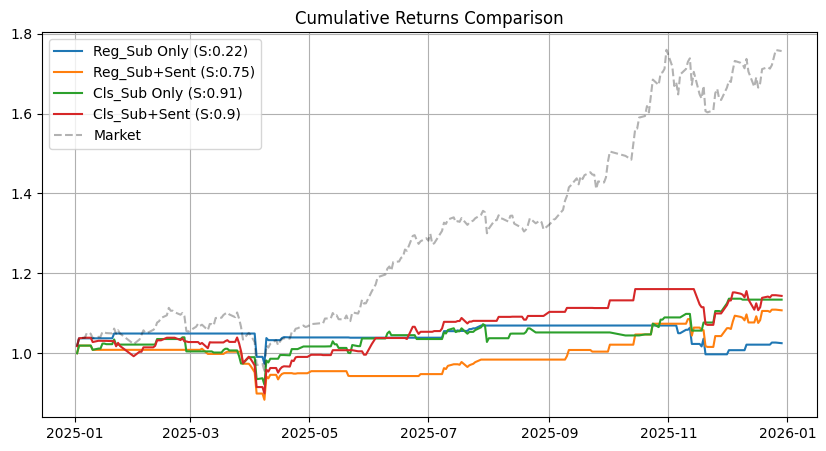

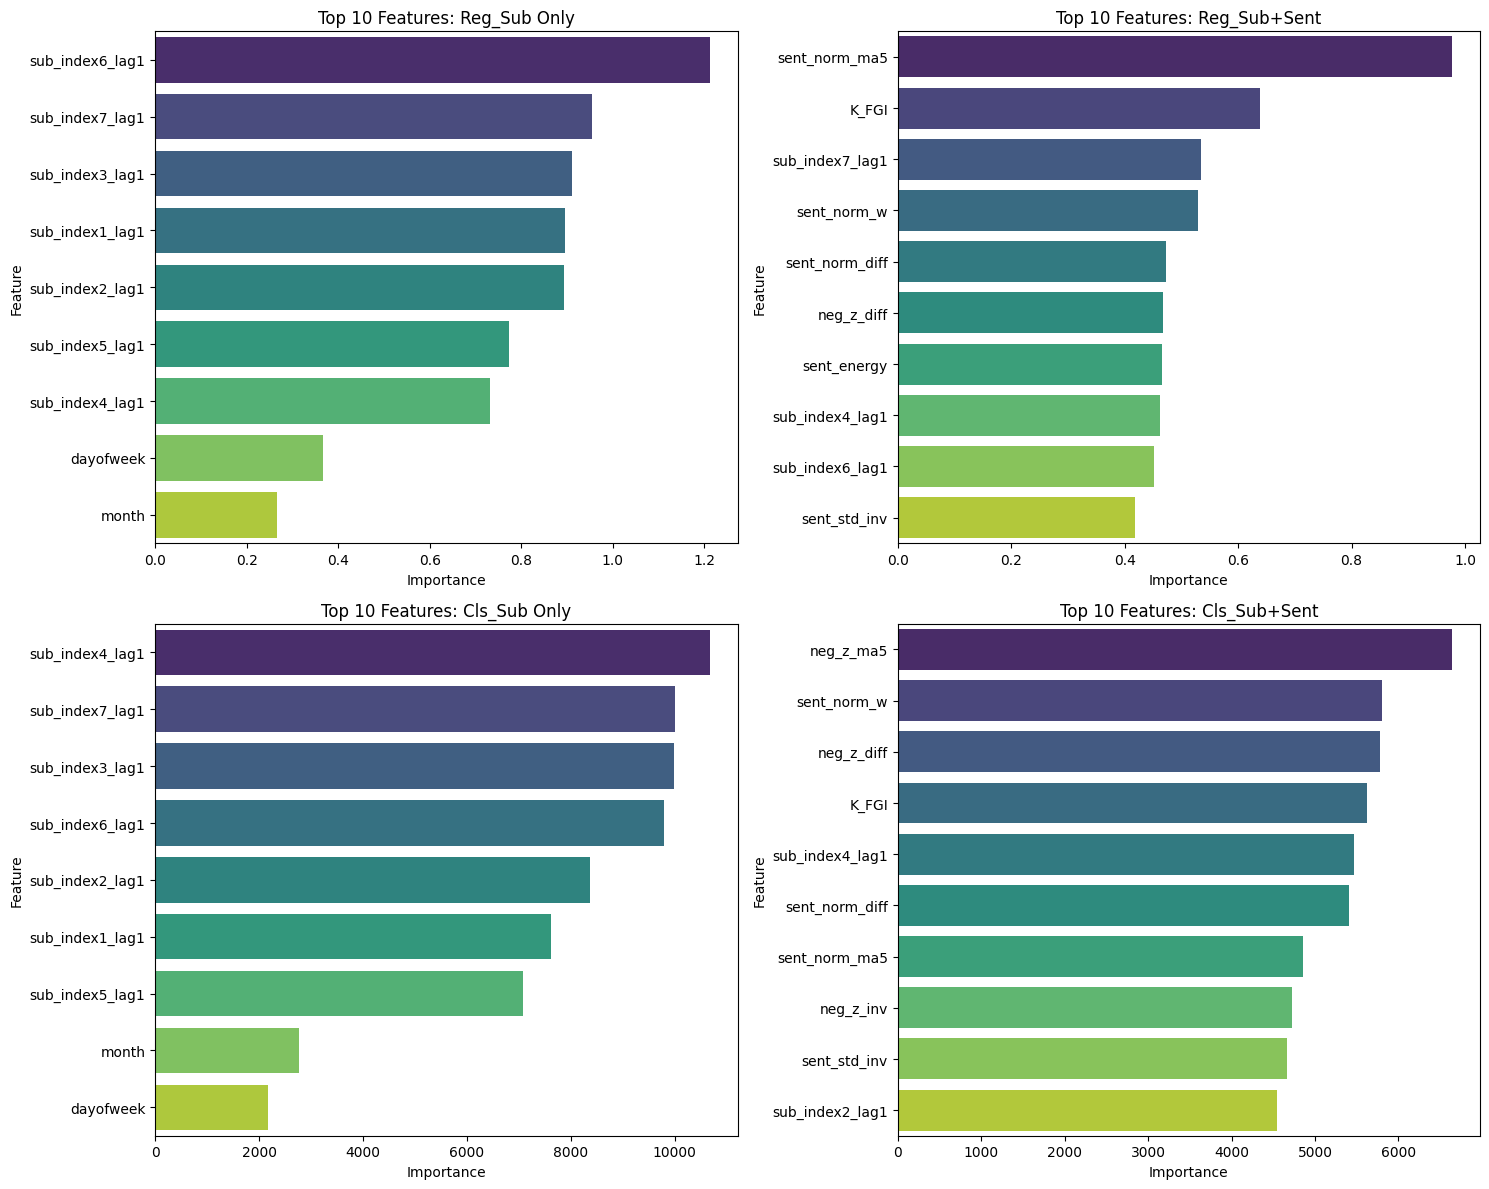


===== 벤치마크 결과 요약 =====
       Model  Sharpe Return
Reg_Sub Only   0.223  2.60%
Reg_Sub+Sent   0.754 10.68%
Cls_Sub Only   0.915 13.17%
Cls_Sub+Sent   0.897 14.03%


In [10]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 가이드 기반 피처 엔지니어링 (동일)
input_file = '/Users/user/Desktop/bitamin/26_winter_proj/data/KFG/KFG_final_2.csv'
df = pd.read_csv(input_file)
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True).fillna(method='ffill').fillna(method='bfill')

def build_advanced_features(df):
    df = df.copy()
    '''
    추후 예측에 사용할 변수 미리 생성
    '''
    df['neg_z_inv'] = -df['neg_z']
    df['sent_std_inv'] = -df['sent_std']
    df['sent_energy'] = df['sent_strength_w'] * df['sent_norm_w']
    df['sent_norm_diff'] = df['sent_norm_w'].diff()
    df['neg_z_diff'] = df['neg_z'].diff()
    df['sent_norm_ma5'] = df['sent_norm_w'].rolling(5).mean()
    df['neg_z_ma5'] = df['neg_z'].rolling(5).mean()

    sub_cols = [f'sub_index{i}' for i in range(1, 8)]
    for col in sub_cols:
        df[f'{col}_lag1'] = df[col].shift(1)

    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    df['target_reg'] = df['log_return_t+1']
    df['target_cls'] = (df['log_return_t+1'] > 0).astype(int)
    df['sample_weight'] = np.log1p(df['effective_n'])

    return df.dropna().reset_index(drop=True)

# 앞으로 사용하게 될 dataset
df_eng = build_advanced_features(df)

# 2. K-FGI 지수 생성 (Ridge)
def create_kfgi(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end
    core_feats = [f'sub_index{i}' for i in range(1, 8)] + \
                 ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv']
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(df.loc[train_mask, core_feats])
    X_all_scaled = scaler.transform(df[core_feats])
    ridge = RidgeCV(alphas=[0.1, 1.0, 10.0]).fit(X_train_scaled, df.loc[train_mask, 'target_reg'])
    w = ridge.coef_ / np.sum(np.abs(ridge.coef_))
    raw = X_all_scaled @ w
    p1, p99 = np.percentile(raw[train_mask], [1, 99])
    df['K_FGI'] = 100 * (np.clip(raw, p1, p99) - p1) / (p99 - p1)
    return df, core_feats, w

df_fgi, core_feats, w = create_kfgi(df_eng)


# 3. 통합 비교 실험 및 피처 중요도 분석
'''
Sub_index만 있는 데이터 vs Sub_index + sentiment 데이터 비교 in Regression, Classification
'''

def run_full_analysis(df, train_end='2024-12-31'):
    train_mask = df['date'] <= train_end
    test_mask = df['date'] > train_end

    sub_only = [f'sub_index{i}_lag1' for i in range(1, 8)] + ['dayofweek', 'month']
    with_sent = sub_only + ['sent_norm_w', 'sent_energy', 'sent_std_inv', 'neg_z_inv',
                            'sent_norm_diff', 'neg_z_diff', 'sent_norm_ma5', 'neg_z_ma5', 'K_FGI']

    experiments = [
        ('Reg', 'Sub Only', sub_only),
        ('Reg', 'Sub+Sent', with_sent),
        ('Cls', 'Sub Only', sub_only),
        ('Cls', 'Sub+Sent', with_sent)
    ]

    summary = []
    fig_cum, ax_cum = plt.subplots(figsize=(10, 5))
    fig_imp, axes_imp = plt.subplots(2, 2, figsize=(15, 12))
    axes_imp = axes_imp.flatten()

    for i, (m_type, f_type, f_list) in enumerate(experiments):
        target = 'target_reg' if m_type == 'Reg' else 'target_cls'

        # 모델 학습
        dtrain = lgb.Dataset(df.loc[train_mask, f_list], label=df.loc[train_mask, target],
                             weight=df.loc[train_mask, 'sample_weight'])
        params = {'objective': 'regression' if m_type == 'Reg' else 'binary', 'verbosity': -1, 'learning_rate': 0.02}
        model = lgb.train(params, dtrain, num_boost_round=300)

        # 예측 및 성과
        preds = model.predict(df.loc[test_mask, f_list])
        actual_ret = df.loc[test_mask, 'log_return_t+1']
        signal = (preds > 0) if m_type == 'Reg' else (preds > 0.5)
        strat_ret = signal * actual_ret

        # 지표 산출
        ann_ret = strat_ret.mean() * 252
        ann_vol = (strat_ret.std() * np.sqrt(252)) + 1e-9
        sharpe = ann_ret / ann_vol

        summary.append({'Model': f"{m_type}_{f_type}", 'Sharpe': round(sharpe, 3), 'Return': f"{ann_ret*100:.2f}%"})

        # 수익 곡선 플롯
        ax_cum.plot(df.loc[test_mask, 'date'], np.exp(strat_ret.cumsum()), label=f"{m_type}_{f_type} (S:{round(sharpe,2)})")

        # 피처 중요도 플롯
        importances = pd.DataFrame({'Feature': f_list, 'Importance': model.feature_importance(importance_type='gain')})
        importances = importances.sort_values(by='Importance', ascending=False).head(10)
        sns.barplot(x='Importance', y='Feature', data=importances, ax=axes_imp[i], palette='viridis')
        axes_imp[i].set_title(f"Top 10 Features: {m_type}_{f_type}")

    # 최종 결과 정리
    ax_cum.plot(df.loc[test_mask, 'date'], np.exp(actual_ret.cumsum()), 'k--', label='Market', alpha=0.3)
    ax_cum.set_title("Cumulative Returns Comparison")
    ax_cum.legend(); ax_cum.grid(True)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame(summary)

# 실행 및 결과 출력
results = run_full_analysis(df_fgi)
print("\n===== 벤치마크 결과 요약 =====")
print(results.to_string(index=False))

# 2. 최종 예측 모형 결정

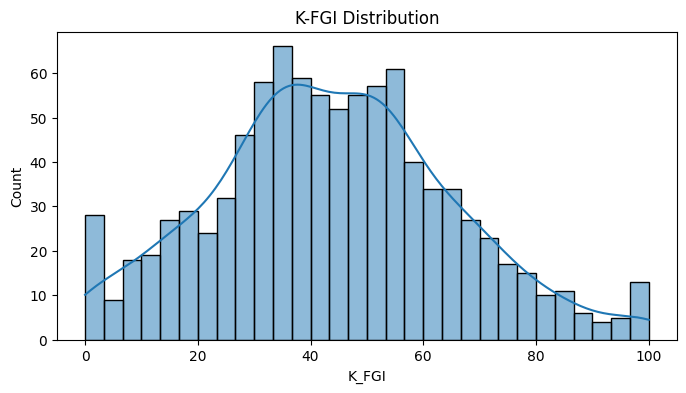

count    934.000000
mean      43.851122
std       21.250990
min        0.000000
25%       30.064857
50%       43.122170
75%       57.243347
max      100.000000
Name: K_FGI, dtype: float64


In [3]:
#%%
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(df_fgi['K_FGI'], bins=30, kde=True)
plt.title("K-FGI Distribution")
plt.show()

print(df_fgi['K_FGI'].describe())
# 결과 꽤나 균등한 분포를 보임

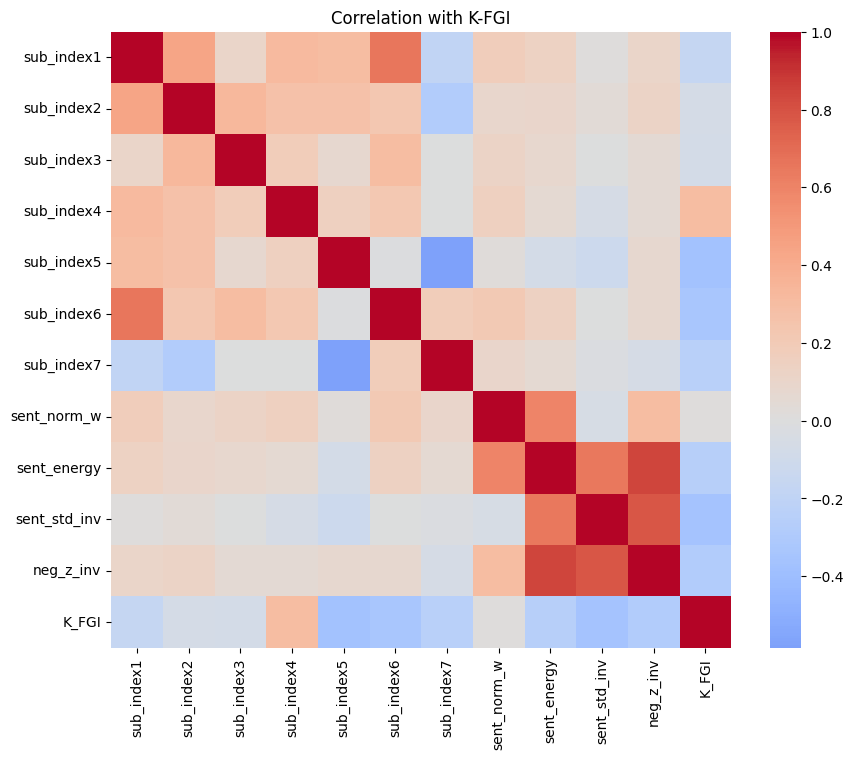

K_FGI           1.000000
sub_index4      0.300914
sent_norm_w     0.012377
sub_index2     -0.069393
sub_index3     -0.071187
sub_index1     -0.167123
sub_index7     -0.239027
sent_energy    -0.253841
neg_z_inv      -0.284407
sub_index6     -0.341962
sent_std_inv   -0.361508
sub_index5     -0.369294
Name: K_FGI, dtype: float64


In [4]:
core_vars = core_feats.copy()
core_vars.append('K_FGI')

corr_matrix = df_fgi[core_vars].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Correlation with K-FGI")
plt.show()

print(corr_matrix['K_FGI'].sort_values(ascending=False))

In [5]:
#%%
fear_zone = df_fgi[df_fgi['K_FGI'] < 20]
greed_zone = df_fgi[df_fgi['K_FGI'] > 80]

print("Fear zone 평균 수익률:", fear_zone['log_return_t+1'].mean())
print("Greed zone 평균 수익률:", greed_zone['log_return_t+1'].mean())

print("Fear count:", len(fear_zone))
print("Greed count:", len(greed_zone))

Fear zone 평균 수익률: -0.0012291880398439797
Greed zone 평균 수익률: 0.00440602270900645
Fear count: 130
Greed count: 49


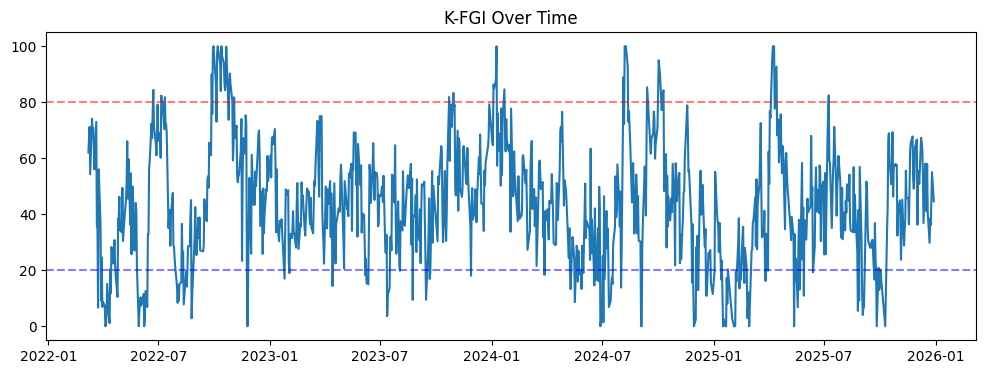

In [6]:
#%%
plt.figure(figsize=(12,4))
plt.plot(df_fgi['date'], df_fgi['K_FGI'])
plt.axhline(20, color='blue', linestyle='--', alpha=0.5)
plt.axhline(80, color='red', linestyle='--', alpha=0.5)
plt.title("K-FGI Over Time")
plt.show()

In [7]:
#%%
print("KFGI vs neg_z correlation:", df_fgi['K_FGI'].corr(df_fgi['neg_z']))
print("KFGI vs sent_norm_w correlation:", df_fgi['K_FGI'].corr(df_fgi['sent_norm_w']))

KFGI vs neg_z correlation: 0.28440731074967057
KFGI vs sent_norm_w correlation: 0.012377469958750394


In [8]:
print(df_fgi['K_FGI'].corr(df_fgi['neg_z_inv']))

-0.28440731074967057


In [11]:
print(pd.Series(w, index=core_feats).sort_values(ascending=False))

neg_z_inv       0.118319
sub_index4      0.103086
sub_index1      0.047311
sent_norm_w     0.033951
sub_index3      0.013787
sub_index2     -0.033519
sub_index6     -0.081448
sent_energy    -0.091719
sub_index7     -0.135242
sent_std_inv   -0.137144
sub_index5     -0.204474
dtype: float64
